In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == "data.yaml":
            print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/data.yaml
/kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov5/data.yaml
/kaggle/input/datasets/khadhimusaid/skripsi-v4/v8/data.yaml
/kaggle/input/datasets/khadhimusaid/skripsi-v4/v5/data.yaml


In [2]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
from ultralytics import YOLO
from tqdm import tqdm
from collections import defaultdict

import matplotlib.pyplot as plt
import json
import cv2
import yaml

model = YOLO("yolov8m.pt")
print("Current model is", model.model_name)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Current model is yolov8m.pt


# Training Model

In [4]:
results = model.train(
    data="/kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/data.yaml",
    seed=42,
    deterministic=True, 
    epochs=500,
    patience=0,
    val=True,
    plots=True,
    verbose=True,
    project='hyperparameter',
    name='yolov8/training'
)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=500, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=training, nbs=64, nms=False, opset=None, optimize=False, optimiz

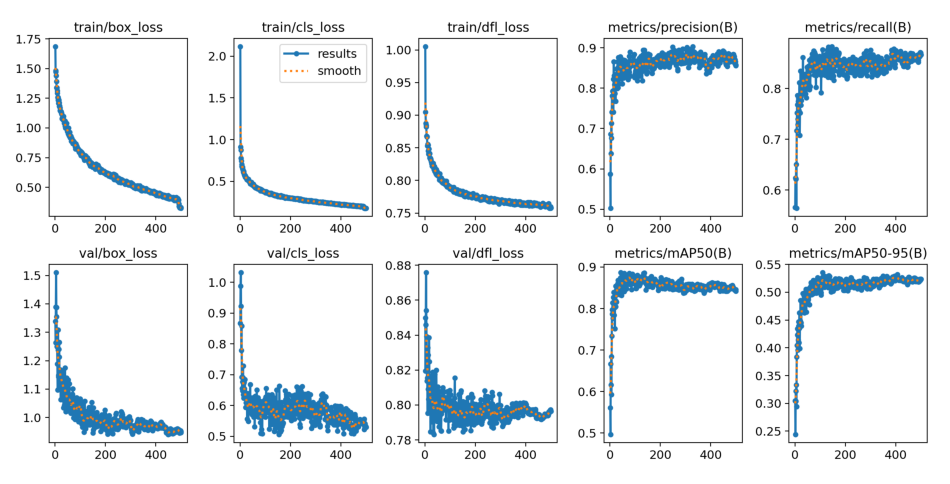

In [5]:
img = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/training/results.png')
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [6]:
v8_best_model = YOLO("/kaggle/working/runs/detect/hyperparameter/yolov8/training/weights/best.pt")

# Validate Model

In [7]:
validate_metrics = v8_best_model.val(
    data='/kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/data.yaml',
    split='val',
    save_json=True,
    visualize=True,
    plots=True,
    project='hyperparameter',
    name='yolov8/validation',
)

# ============================================================
# 3. PRINT METRICS VALIDATION
# ============================================================
print("===== VALIDATION RESULT =====")
print("mAP50      :", validate_metrics.box.map50)
print("mAP50-95   :", validate_metrics.box.map)
print("Precision  :", validate_metrics.box.mp)
print("Recall     :", validate_metrics.box.mr)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 198.8±49.7 MB/s, size: 328.3 KB)
val: Scanning /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/valid/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 413.2it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5s/it 4.5s
                   all         35        424      0.818      0.877      0.879      0.534
             no_gloves         24         87      0.681      0.713        0.7      0.325
            no_hairnet         18         25       0.88          1      0.971      0.788
               no_mask         20         31      0.776      0.935  

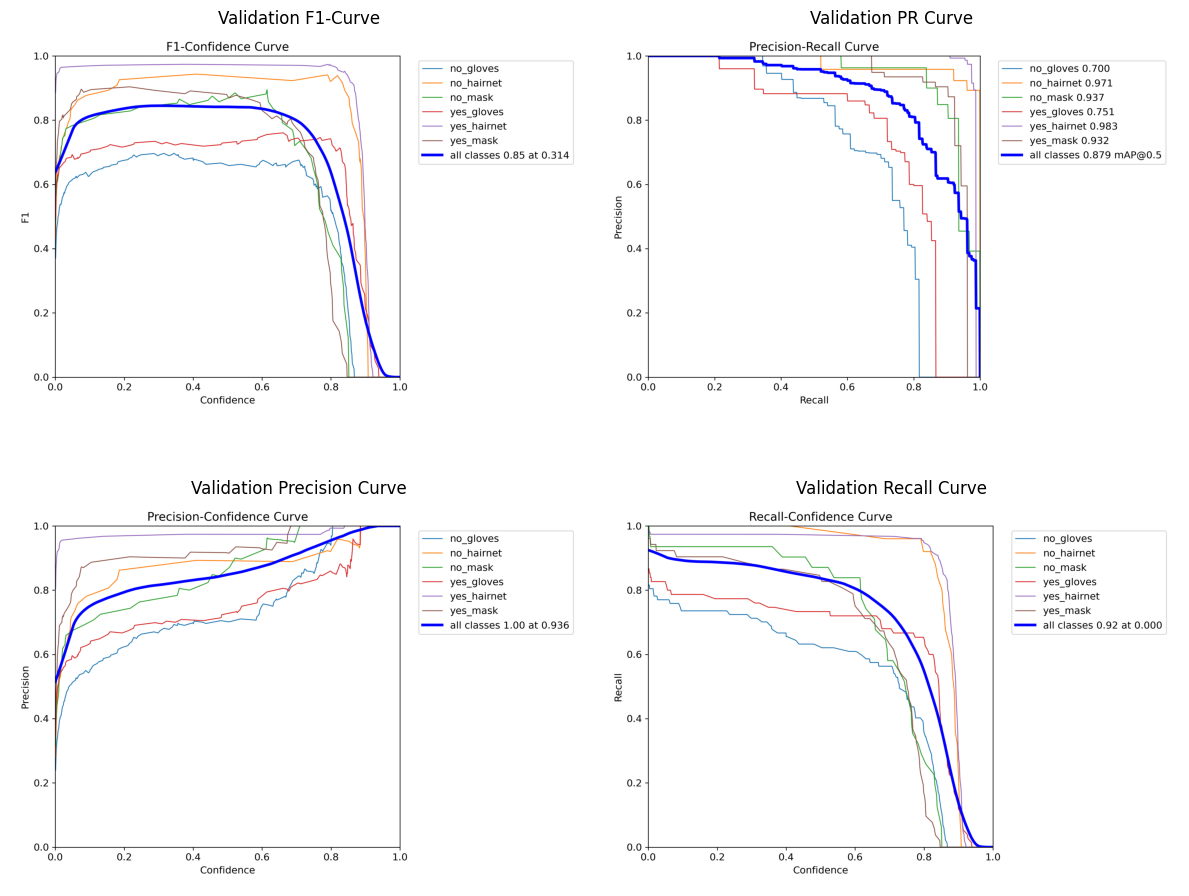

In [8]:
img1 = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/validation/BoxF1_curve.png')
img2 = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/validation/BoxPR_curve.png')
img3 = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/validation/BoxP_curve.png')
img4 = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/validation/BoxR_curve.png')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img1)
axes[0, 0].axis('off')
axes[0, 0].set_title('Validation F1-Curve')

axes[0, 1].imshow(img2)
axes[0, 1].axis('off')
axes[0, 1].set_title('Validation PR Curve')

axes[1, 0].imshow(img3)
axes[1, 0].axis('off')
axes[1, 0].set_title('Validation Precision Curve')

axes[1, 1].imshow(img4)
axes[1, 1].axis('off')
axes[1, 1].set_title('Validation Recall Curve')

plt.tight_layout()
plt.show()

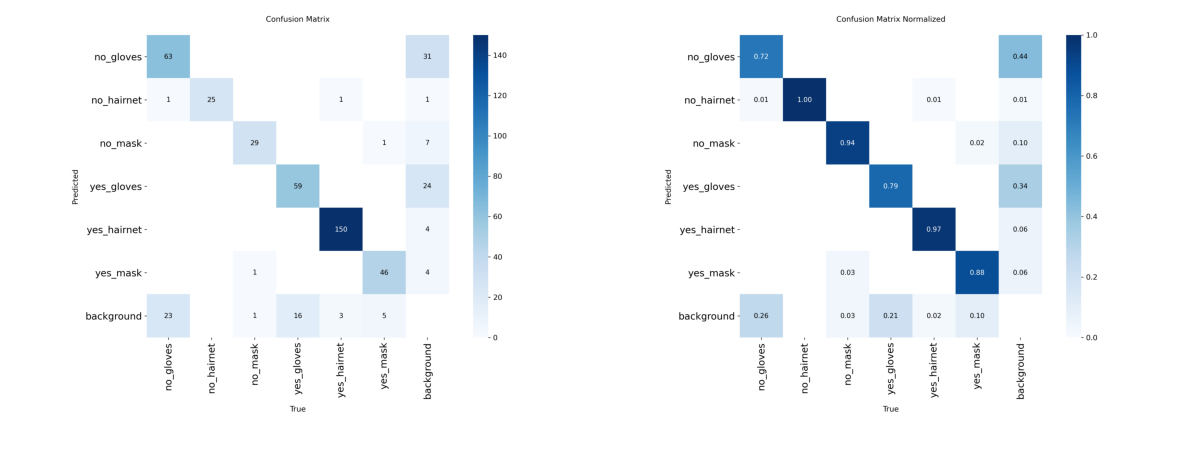

In [9]:
conf_matrix_val = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/validation/confusion_matrix.png')
conf_matrix_nr_val = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/validation/confusion_matrix_normalized.png')

conf_matrix_val = cv2.cvtColor(conf_matrix_val, cv2.COLOR_BGR2RGB)
conf_matrix_nr_val = cv2.cvtColor(conf_matrix_nr_val, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].imshow(conf_matrix_val); axes[0].axis('off'); axes[0]
axes[1].imshow(conf_matrix_nr_val); axes[1].axis('off'); axes[1]
plt.tight_layout()
plt.show()

# Test Model

In [10]:
# ================================
# TEST CONFIG
# ================================
DATA_YAML  = "/kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/data.yaml"
IOU_NMS    = 0.7
IOU_MATCH  = 0.5

# ================================
# TESTING (YOLO BUILT-IN)
# ================================
metrics = v8_best_model.val(
    data=DATA_YAML,
    split="test",
    iou=IOU_NMS,
    verbose=True,
    save_json=True,
    plots=True,
    project='hyperparameter',
    name='yolov8/testing',
)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 2.7±1.9 ms, read: 34.0±5.5 MB/s, size: 299.9 KB)
val: Scanning /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 103.7it/s 0.3s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.3it/s 2.4s
                   all         35        359      0.865      0.855      0.874      0.522
             no_gloves         20         61      0.853      0.852      0.852      0.359
            no_hairnet         22         40      0.972       0.95      0.944      0.801
               no_mask         24         35      0.781        0.8      0.843      0.345
            yes_gloves         22         81      0.702      0.65

In [11]:
# ================================
# AMBIL GAMBAR TEST
# ================================
def get_test_images():
    from pathlib import Path

    test_path = Path("/kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/test/images")

    print("Resolved test path:", test_path)

    images = list(test_path.glob("*.jpg")) + \
             list(test_path.glob("*.png")) + \
             list(test_path.glob("*.jpeg"))

    print("Jumlah gambar:", len(images))

    return sorted(images)


# ================================
# LOAD GT (CLS + BBOX)
# ================================
def load_gt_boxes(label_path, img_w, img_h):
    boxes = []

    if not Path(label_path).exists():
        return boxes

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        cls, x, y, w, h = map(float, parts)

        x1 = (x - w/2) * img_w
        y1 = (y - h/2) * img_h
        x2 = (x + w/2) * img_w
        y2 = (y + h/2) * img_h

        boxes.append((int(cls), [x1, y1, x2, y2]))

    return boxes

In [12]:
# ================================
# IOU
# ================================
def bbox_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    return inter / union if union > 0 else 0
    
# ================================
# MATCHING
# ================================
def match_detections(pred_boxes, gt_boxes, iou_threshold=IOU_MATCH):

    TP_c = defaultdict(int)
    FP_c = defaultdict(int)
    FN_c = defaultdict(int)

    if len(pred_boxes) == 0 and len(gt_boxes) == 0:
        return TP_c, FP_c, FN_c

    if len(pred_boxes) == 0:
        for cls, _ in gt_boxes:
            FN_c[cls] += 1
        return TP_c, FP_c, FN_c

    if len(gt_boxes) == 0:
        for cls, _ in pred_boxes:
            FP_c[cls] += 1
        return TP_c, FP_c, FN_c

    iou_matrix = np.zeros((len(pred_boxes), len(gt_boxes)))

    for i, (cls_p, box_p) in enumerate(pred_boxes):
        for j, (cls_g, box_g) in enumerate(gt_boxes):
            if cls_p != cls_g:
                iou_matrix[i, j] = 0
            else:
                iou_matrix[i, j] = bbox_iou(box_p, box_g)

    matched_pred = set()
    matched_gt = set()

    indices = np.dstack(np.unravel_index(
        np.argsort(iou_matrix.ravel())[::-1],
        iou_matrix.shape
    ))[0]

    for i, j in indices:
        if i in matched_pred or j in matched_gt:
            continue

        if iou_matrix[i, j] < iou_threshold:
            break

        cls = gt_boxes[j][0]
        TP_c[cls] += 1

        matched_pred.add(i)
        matched_gt.add(j)

    # FP
    for i, (cls, _) in enumerate(pred_boxes):
        if i not in matched_pred:
            FP_c[cls] += 1

    # FN
    for j, (cls, _) in enumerate(gt_boxes):
        if j not in matched_gt:
            FN_c[cls] += 1

    return TP_c, FP_c, FN_c

In [13]:
# ================================
# EVALUASI TEST
# ================================
print("\n===== TESTING MANUAL MODEL YOLOv8 =====")

test_images = get_test_images()

TP_total = defaultdict(int)
FP_total = defaultdict(int)
FN_total = defaultdict(int)

for img_path in tqdm(test_images):

    img = cv2.imread(str(img_path))
    if img is None:
        continue

    h, w = img.shape[:2]

    label_path = str(img_path).replace("/images/", "/labels/").replace(".jpg", ".txt")

    gt_boxes = load_gt_boxes(label_path, w, h)

    results = v8_best_model.predict(str(img_path), iou=IOU_NMS, verbose=True)
    boxes = results[0].boxes

    pred_boxes = []
    if boxes is not None:
        for b, c in zip(boxes.xyxy.cpu().numpy(), boxes.cls.cpu().numpy()):
            pred_boxes.append((int(c), b.tolist()))

    TP_c, FP_c, FN_c = match_detections(pred_boxes, gt_boxes, IOU_MATCH)

    for k in TP_c:
        TP_total[k] += TP_c[k]
    for k in FP_c:
        FP_total[k] += FP_c[k]
    for k in FN_c:
        FN_total[k] += FN_c[k]


===== TESTING MANUAL MODEL YOLOv8 =====
Resolved test path: /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/test/images
Jumlah gambar: 35


  0%|          | 0/35 [00:00<?, ?it/s]


image 1/1 /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/test/images/20260225125406114_FY0213996_hcDownloadP_Camera-Persiapan_4_video_MOV-0015_jpg.rf.442e5b4b1d7ab7381652f00b3b7a2013.jpg: 384x640 1 no_gloves, 3 no_hairnets, 2 no_masks, 6 yes_glovess, 1 yes_hairnet, 52.5ms
Speed: 2.6ms preprocess, 52.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


  3%|▎         | 1/35 [00:00<00:05,  5.84it/s]


image 1/1 /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/test/images/20260225125406114_FY0213996_hcDownloadP_Camera-Persiapan_4_video_MOV-0017_jpg.rf.47b763a552a370710d8c43433f7429c7.jpg: 384x640 1 no_gloves, 3 no_hairnets, 2 no_masks, 6 yes_glovess, 1 yes_hairnet, 24.9ms
Speed: 2.2ms preprocess, 24.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/test/images/20260225125406114_FY0213996_hcDownloadP_Camera-Persiapan_4_video_MOV-0018_jpg.rf.a0618068e3580b385dec5c50a1d9a94d.jpg: 384x640 1 no_gloves, 3 no_hairnets, 2 no_masks, 5 yes_glovess, 1 yes_hairnet, 24.9ms
Speed: 1.8ms preprocess, 24.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


...

 89%|████████▊ | 31/35 [00:01<00:00, 18.27it/s]


image 1/1 /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/test/images/vid_4_MOV-0017_jpg.rf.df0be01a3b497f8ea96272da6acfadb9.jpg: 384x640 3 no_hairnets, 2 no_masks, 1 yes_gloves, 1 yes_hairnet, 19.7ms
Speed: 1.8ms preprocess, 19.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/test/images/vid_5_MOV-0002_jpg.rf.f85faaad9d8d35a5763c6908ffd83813.jpg: 384x640 2 no_hairnets, 1 no_mask, 3 yes_glovess, 19.8ms
Speed: 1.9ms preprocess, 19.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


 94%|█████████▍| 33/35 [00:01<00:00, 18.38it/s]


image 1/1 /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/test/images/vid_5_MOV-0014_jpg.rf.100ae363179b06ff837c097af247b70b.jpg: 384x640 2 no_hairnets, 1 no_mask, 2 yes_glovess, 19.7ms
Speed: 1.8ms preprocess, 19.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /kaggle/input/datasets/khadhimusaid/skripsi-v5/v5/yolov8/test/images/vid_5_MOV-0015_jpg.rf.0707350fe63aaa0b78169407664e49cf.jpg: 384x640 2 no_hairnets, 2 yes_glovess, 19.7ms
Speed: 1.7ms preprocess, 19.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


100%|██████████| 35/35 [00:02<00:00, 16.67it/s]


In [14]:
# ================================
# OUTPUT PER CLASS
# ================================
print("\n===== HASIL PER CLASS =====")

all_classes = set(TP_total.keys()) | set(FP_total.keys()) | set(FN_total.keys())

for cls in sorted(all_classes):
    TP = TP_total[cls]
    FP = FP_total[cls]
    FN = FN_total[cls]

    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0

    print(f"\nClass {cls}")
    print(f"TP: {TP} | FP: {FP} | FN: {FN}")

# ================================
# OVERALL
# ================================
TP_sum = sum(TP_total.values())
FP_sum = sum(FP_total.values())
FN_sum = sum(FN_total.values())

print("\n===== OVERALL =====")
print(f"TP: {TP_sum} | FP: {FP_sum} | FN: {FN_sum}")


===== HASIL PER CLASS =====

Class 0
TP: 52 | FP: 18 | FN: 9

Class 1
TP: 38 | FP: 1 | FN: 2

Class 2
TP: 31 | FP: 13 | FN: 4

Class 3
TP: 56 | FP: 26 | FN: 25

Class 4
TP: 113 | FP: 1 | FN: 2

Class 5
TP: 24 | FP: 4 | FN: 3

===== OVERALL =====
TP: 314 | FP: 63 | FN: 45


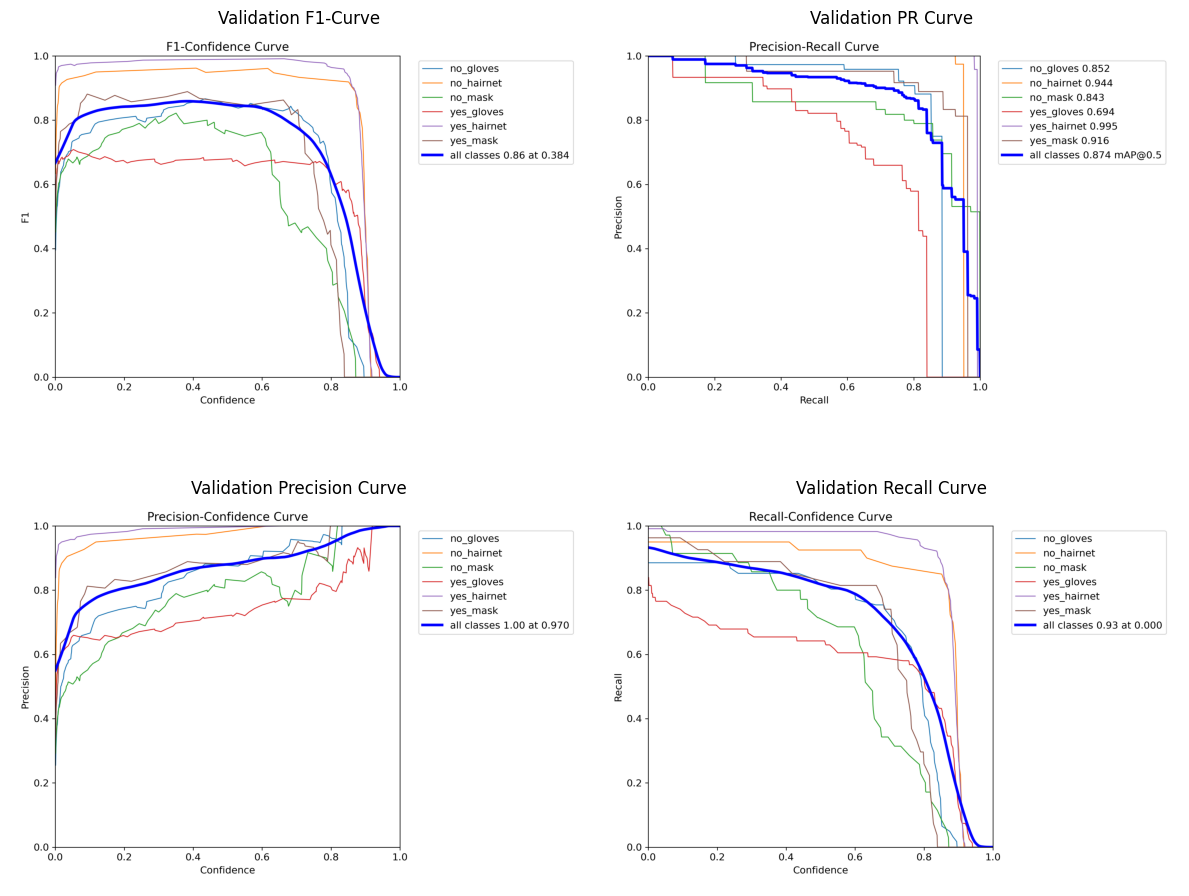

In [15]:
img1 = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/testing/BoxF1_curve.png')
img2 = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/testing/BoxPR_curve.png')
img3 = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/testing/BoxP_curve.png')
img4 = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/testing/BoxR_curve.png')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img1)
axes[0, 0].axis('off')
axes[0, 0].set_title('Validation F1-Curve')

axes[0, 1].imshow(img2)
axes[0, 1].axis('off')
axes[0, 1].set_title('Validation PR Curve')

axes[1, 0].imshow(img3)
axes[1, 0].axis('off')
axes[1, 0].set_title('Validation Precision Curve')

axes[1, 1].imshow(img4)
axes[1, 1].axis('off')
axes[1, 1].set_title('Validation Recall Curve')

plt.tight_layout()
plt.show()

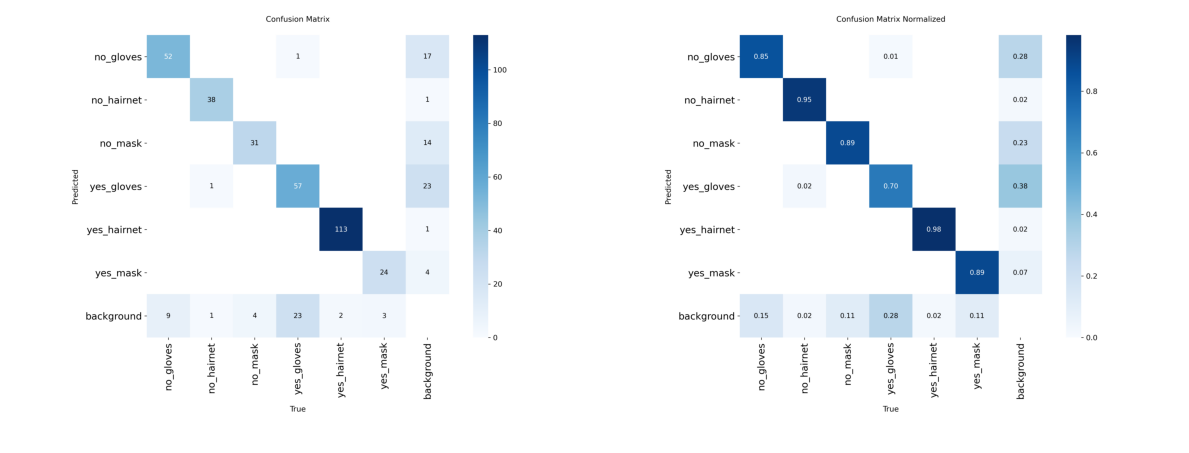

In [16]:
conf_matrix_val = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/testing/confusion_matrix.png')
conf_matrix_nr_val = cv2.imread('/kaggle/working/runs/detect/hyperparameter/yolov8/testing/confusion_matrix_normalized.png')

conf_matrix_val = cv2.cvtColor(conf_matrix_val, cv2.COLOR_BGR2RGB)
conf_matrix_nr_val = cv2.cvtColor(conf_matrix_nr_val, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 10))
axes[0].imshow(conf_matrix_val); axes[0].axis('off'); axes[0]
axes[1].imshow(conf_matrix_nr_val); axes[1].axis('off'); axes[1]
plt.tight_layout()
plt.show()

In [17]:
v8_best_model.model.info()

Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


(93, 25843234, 0, 78.7047936)

In [18]:
model_path = '/kaggle/working/runs/detect/hyperparameter/yolov8/training/weights/best.pt'
size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"Model file size: {size_mb:.2f} MB")

Model file size: 49.66 MB
